In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.shape


(1000, 9)

In [5]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [6]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## Initial inspection

The dataset contains 1000 rows and 9 columns. There are no missing 
values in any column. Most columns have appropriate data types 
(int64 for numerical fields), except Date, which is currently stored 
as an object (string) and will need to be converted to datetime 
format for time series analysis.

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
for col in ['Age', 'Quantity', 'Price per Unit', 'Total Amount']:
    print(f"{col} mean: {df[col].mean()}")
    print(f"{col} median: {df[col].median()}")
    print(f"{col} mode: {df[col].mode()[0]}")
    print(f"{col} std: {df[col].std()}")
    print("---")

Age mean: 41.392
Age median: 42.0
Age mode: 43
Age std: 13.681429659122527
---
Quantity mean: 2.514
Quantity median: 3.0
Quantity mode: 4
Quantity std: 1.1327343409145356
---
Price per Unit mean: 179.89
Price per Unit median: 50.0
Price per Unit mode: 50
Price per Unit std: 189.68135627129232
---
Total Amount mean: 456.0
Total Amount median: 135.0
Total Amount mode: 50
Total Amount std: 559.997631555123
---


## Descriptive Statistics

The average customer age is 41.4 years (median 42, mode 43), showing 
a fairly even age distribution. For Total Amount, the mean (456.0) is 
much higher than the median (135.0), indicating that a small number of 
high-value transactions are pulling the average up — most purchases 
are actually smaller. The same pattern appears in Price per Unit 
(mean 179.89 vs median 50.0), suggesting a mix of low-cost and 
occasional high-cost products in the store's catalog.

In [9]:
df['Date'] = pd.to_datetime(df['Date']) 
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

In [10]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()
print(monthly_sales)

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


In [13]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()
print(quarterly_sales)

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


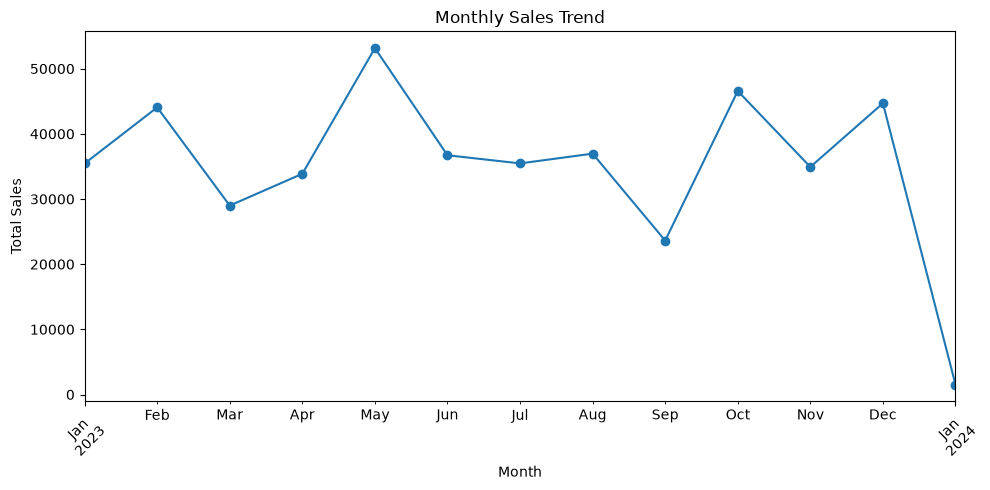

In [11]:
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

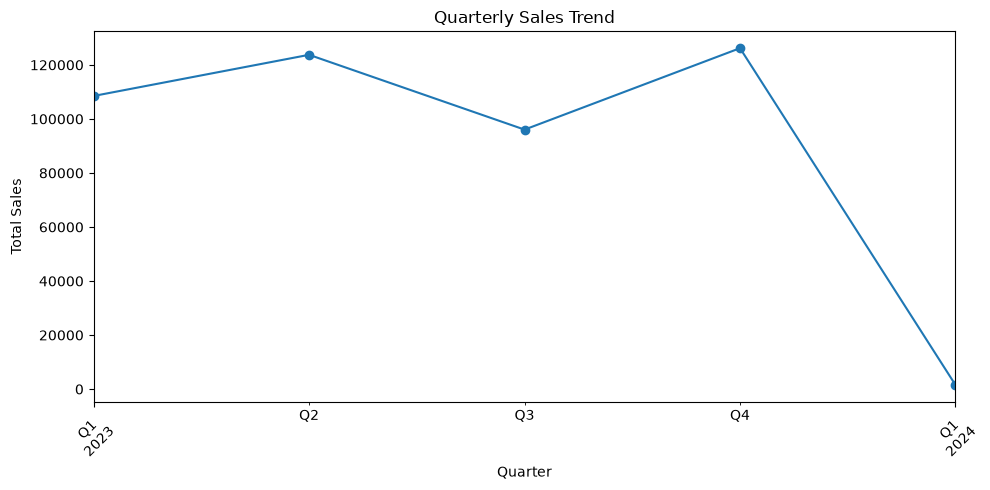

In [16]:
plt.figure(figsize=(10, 5))
quarterly_sales.plot(kind='line', marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Time Series Analysis

Monthly sales fluctuate without a clear consistent upward or downward 
trend, with peaks in May, September, and November and dips in April 
and August. Quarterly sales are relatively stable through 2023 
(ranging from ~96,000 to ~126,000), with the sharp drop shown for 
2024 Q1 being a data artifact — the dataset only contains a few 
transactions from January 2024, not an actual decline in sales.

In [19]:
bins = [17, 25, 35, 45, 55, 65, 100] 
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+'] 
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels) 
df['Age Group'].value_counts() 


Age Group
46-55    229
26-35    205
36-45    202
56-65    195
18-25    169
65+        0
Name: count, dtype: int64

In [25]:
df.groupby('Age Group')['Total Amount'].sum().sort_values(ascending=False)

C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_8228\2552858651.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')['Total Amount'].sum().sort_values(ascending=False)


Age Group
46-55    100690
26-35     98480
36-45     91870
18-25     84550
56-65     80410
65+           0
Name: Total Amount, dtype: int64

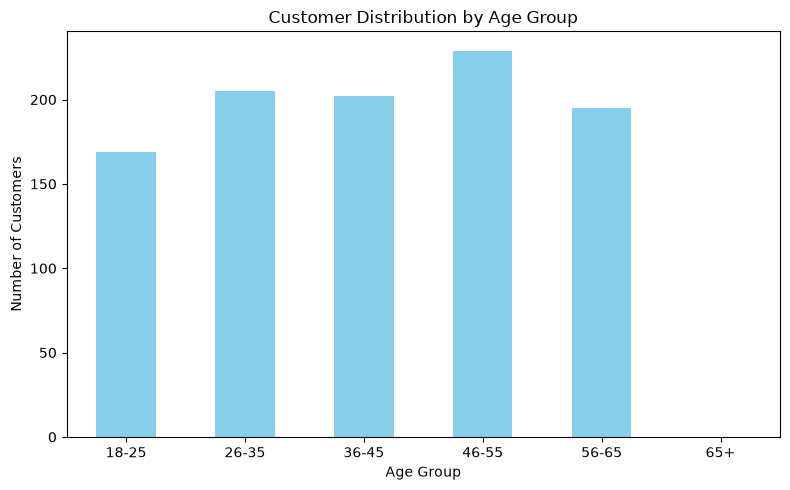

In [20]:
plt.figure(figsize=(8, 5))
df['Age Group'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
df['Gender'].value_counts()


Gender
Female    510
Male      490
Name: count, dtype: int64

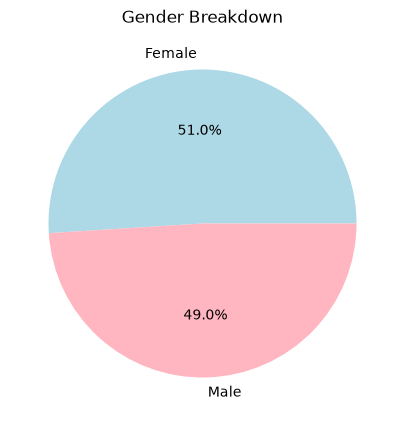

In [23]:
plt.figure(figsize=(5, 5))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightpink'])
plt.title('Gender Breakdown')
plt.ylabel('')
plt.show()

## Customer Demographics

The customer base is almost evenly split by gender (51% Female, 49% 
Male). Age is well distributed across groups, with 46-55 being the 
largest contributor to revenue (100,690), followed closely by 26-35 
(98,480). No customers fall into the 65+ age group in this dataset.

In [28]:
print("Products:", df['Product Category'].unique()) 

Products: ['Beauty' 'Clothing' 'Electronics']


Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


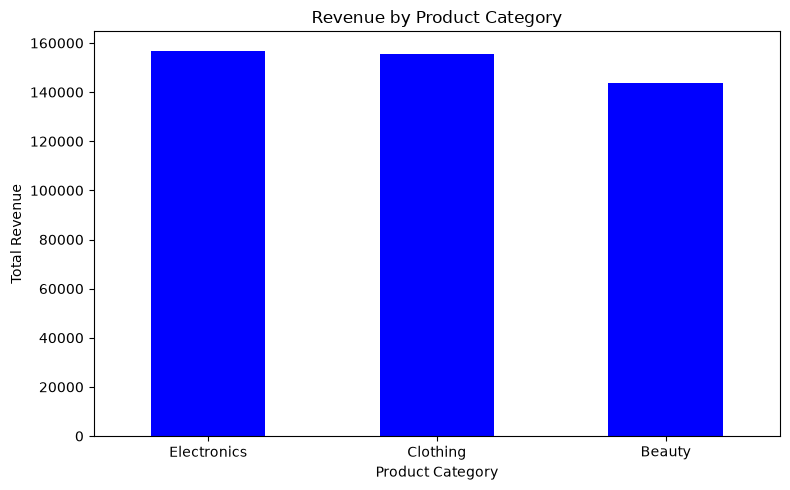

In [30]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False) 
print(category_revenue)
plt.figure(figsize=(8, 5)) 
category_revenue.plot(kind='bar', color='blue') 
plt.title('Revenue by Product Category') 
plt.xlabel('Product Category') 
plt.ylabel('Total Revenue') 
plt.xticks(rotation=0) 
plt.tight_layout() 
plt.show()

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


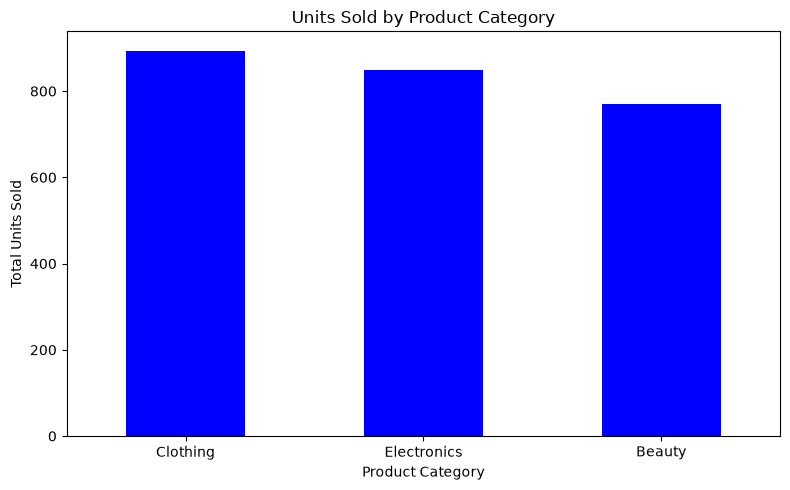

In [32]:
category_qty = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False) 
print(category_qty) 
plt.figure(figsize=(8, 5)) 
category_qty.plot(kind='bar', color='blue') 
plt.title('Units Sold by Product Category') 
plt.xlabel('Product Category') 
plt.ylabel('Total Units Sold') 
plt.xticks(rotation=0) 
plt.tight_layout() 
plt.show() 

## Product Analysis

Electronics generates the highest revenue (156,905), followed closely 
by Clothing (155,580), with Beauty lowest (143,515). However, when 
looking at units sold, Clothing leads (894 units), ahead of Electronics 
(849) and Beauty (771). This suggests Electronics items have a higher 
average price per unit, making them the top revenue driver despite 
selling slightly fewer units than Clothing.

